# ETF Markowitz universe — ML buy/sell signal

An XGBoost buy/sell classifier for ETFs, mirroring `Main.ipynb`'s stock pipeline
(vol-scaled labels, same model config) but with the feature superset **minus all
stock fundamentals and earnings-event features** (ETFs have neither).

**Key idea — train on breadth, deploy on the 7.** The All-Weather/Markowitz
portfolio holds 7 highly-correlated US-equity ETFs (`QQQ, VOO, VGT, SOXX, QUAL,
VBR, VTV`). A cross-sectional signal over only those 7 is hopeless, so the model
trains/tests on a **broad ~60–80 US-equity ETF universe** (sector + industry +
style/factor). All bars are **weekly W-FRI**.

Scope: *buy/sell signal only* — feature → label → train → classifier evaluation.
Portfolio construction / weighting / weighted backtest are deliberately deferred.

Reuses the repo's pure helpers (`src/indicators.py`, `classify_regimes`,
`extract_ticker_dataframe`); ports the superset feature builder, vol-scaled
labeling, and XGBoost config from `Main.ipynb`.

In [1]:
import os, sys, warnings
sys.path.append("src")

import numpy as np
import pandas as pd
import yfinance as yf
import requests
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import indicators
from lib import classify_regimes, extract_ticker_dataframe

load_dotenv()
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
print("imports ok")

imports ok


In [2]:
# ---------------- config ----------------
PORTFOLIO = ["QQQ", "VOO", "VGT", "SOXX", "QUAL", "VBR", "VTV"]   # deployment set

# Broad ~60-80 liquid US-equity ETF training universe (PORTFOLIO is a subset).
_BROAD_STYLE = ["SPY", "VOO", "QQQ", "IWM", "IWB", "IWD", "IWF", "VUG", "VTV",
                "VBR", "VBK", "VOE", "MTUM", "QUAL", "VLUE", "USMV", "SPLV",
                "RSP", "SCHD", "VIG", "VYM"]
_SECTOR_SPDR = ["XLK", "XLF", "XLE", "XLV", "XLI", "XLY", "XLP", "XLU", "XLB",
                "XLRE", "XLC"]
_VANGUARD    = ["VGT", "VHT", "VFH", "VDE", "VIS", "VCR", "VDC", "VPU", "VAW",
                "VOX", "VNQ"]
_INDUSTRY    = ["SOXX", "SMH", "IGV", "SKYY", "FDN", "XBI", "IBB", "IHI", "XHB",
                "ITB", "KRE", "KBE", "XOP", "OIH", "XME", "JETS", "TAN", "ICLN",
                "XRT", "ARKK"]
TRAIN_UNIVERSE = sorted(set(_BROAD_STYLE + _SECTOR_SPDR + _VANGUARD + _INDUSTRY
                            + PORTFOLIO))

BENCH        = "^GSPC"
DATA_START   = "2015-01-01"
OHLCV_CSV    = "data/etf_ohlcv.csv"
MIN_WEEKS    = 104          # ~2 yr; needed for 26-wk beta/momentum + 12-wk vol
K            = 0.60         # vol-scaling multiplier for buy/sell labels (Main's K)
USE_MACRO    = True         # FRED macro features (toggle off to drop them)
FORCE_REFRESH = False       # re-download prices even if cache is fresh

print(f"{len(TRAIN_UNIVERSE)} ETFs in TRAIN_UNIVERSE; deploying on {PORTFOLIO}")

63 ETFs in TRAIN_UNIVERSE; deploying on ['QQQ', 'VOO', 'VGT', 'SOXX', 'QUAL', 'VBR', 'VTV']


## 1. Data — weekly W-FRI OHLCV (cached), S&P 500 frame, FRED macro

In [3]:
def _last_friday():
    today = pd.Timestamp.today().normalize()
    return today - pd.Timedelta(days=(today.weekday() - 4) % 7)


def _fetch_one_ohlcv(ticker, start=DATA_START):
    """Daily auto-adjusted OHLCV -> weekly W-FRI, columns suffixed {Field}_{ticker}."""
    df = yf.download(ticker, interval="1d", start=start,
                     auto_adjust=True, progress=False)
    if df is None or df.empty:
        return None
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df[["Open", "High", "Low", "Close", "Volume"]]
    wk = df.resample("W-FRI").agg({"Open": "first", "High": "max", "Low": "min",
                                   "Close": "last", "Volume": "sum"})
    wk.columns = [f"{c}_{ticker}" for c in wk.columns]
    return wk


def download_etf_ohlcv(tickers, csv_path=OHLCV_CSV, start=DATA_START,
                       force_refresh=False):
    """Wide multi-ticker weekly OHLCV ({Field}_{TICKER}); cached to csv_path.
    Re-downloads the whole set only if the cache is missing/stale (last row older
    than the most recent Friday)."""
    threshold = _last_friday() - pd.Timedelta(days=1)
    if not force_refresh and os.path.exists(csv_path):
        cached = pd.read_csv(csv_path, parse_dates=["Date"]).set_index("Date")
        if not cached.empty and cached.index.max() >= threshold:
            print(f"using cached {csv_path} (through {cached.index.max().date()})")
            return cached

    frames, missing = [], []
    for t in tickers:
        wk = _fetch_one_ohlcv(t, start)
        if wk is None:
            missing.append(t)
            continue
        frames.append(wk)
    if missing:
        print(f"  ! no data for: {', '.join(missing)}")
    combined = pd.concat(frames, axis=1).sort_index().ffill()
    combined.index.name = "Date"
    os.makedirs(os.path.dirname(csv_path) or ".", exist_ok=True)
    combined.to_csv(csv_path)
    print(f"wrote {csv_path}: {combined.shape[0]} weeks x {combined.shape[1]} cols")
    return combined


ohlcv = download_etf_ohlcv(TRAIN_UNIVERSE, force_refresh=FORCE_REFRESH)

# ---- min-history filter ----
def surviving_universe(ohlcv, tickers, min_weeks=MIN_WEEKS):
    keep = []
    for t in tickers:
        col = f"Close_{t}"
        if col in ohlcv.columns and ohlcv[col].notna().sum() >= min_weeks:
            keep.append(t)
    return keep

UNIVERSE = surviving_universe(ohlcv, TRAIN_UNIVERSE)
dropped = sorted(set(TRAIN_UNIVERSE) - set(UNIVERSE))
print(f"{len(UNIVERSE)} ETFs survive the >={MIN_WEEKS}-week filter; dropped: {dropped}")
print("portfolio ETFs present:", [t for t in PORTFOLIO if t in UNIVERSE])

using cached data/etf_ohlcv.csv (through 2026-05-29)
63 ETFs survive the >=104-week filter; dropped: []
portfolio ETFs present: ['QQQ', 'VOO', 'VGT', 'SOXX', 'QUAL', 'VBR', 'VTV']


In [4]:
# ---- S&P 500 weekly frame: Log_Returns + 6-wk return (for regime/beta/market) ----
_raw = yf.download(BENCH, interval="1d", start=DATA_START, auto_adjust=True,
                   progress=False)
if isinstance(_raw.columns, pd.MultiIndex):
    _raw.columns = _raw.columns.get_level_values(0)
sp500 = _raw["Close"].resample("W-FRI").last().to_frame("Close_^GSPC")
sp500["Log_Returns"] = np.log(sp500["Close_^GSPC"] / sp500["Close_^GSPC"].shift(1))
sp500["Returns_6wk"] = sp500["Close_^GSPC"].pct_change(6)
sp500.index.name = "Date"
sp500 = sp500.dropna()
print(f"sp500: {len(sp500)} weeks {sp500.index.min().date()} -> {sp500.index.max().date()}")

sp500: 590 weeks 2015-02-13 -> 2026-05-29


In [5]:
# ---- FRED macro (PCE inflation, Fed Funds, unemployment) ----
import time as _time

def _fred_get(params, retries=4):
    """GET FRED observations with backoff on 429 (rate limit)."""
    for attempt in range(retries):
        resp = requests.get("https://api.stlouisfed.org/fred/series/observations",
                            params=params, timeout=30).json()
        if "observations" in resp:
            return resp
        if resp.get("error_code") == 429 and attempt < retries - 1:
            _time.sleep(1.5 * (attempt + 1))
            continue
        raise RuntimeError(f"FRED error: {resp.get('error_message', resp)}")
    raise RuntimeError("FRED: retries exhausted")


def get_fred_data(measures, api_key, start="1999-01-01", end=None):
    end = end or pd.Timestamp.today().strftime("%Y-%m-%d")
    ret = None
    for measure in measures:
        params = {"series_id": measure, "api_key": api_key, "file_type": "json",
                  "observation_start": start, "observation_end": end}
        resp = _fred_get(params)
        _time.sleep(0.6)   # stay under FRED's burst rate limit
        recs = [{"date": o["date"],
                 measure: (float(o["value"]) if o["value"] != "." else None)}
                for o in resp["observations"]]
        df = pd.DataFrame(recs)
        df["date"] = pd.to_datetime(df["date"])
        ret = df if ret is None else ret.merge(df, on="date", how="left")
    return ret

fred_data = None
if USE_MACRO:
    try:
        _api = os.environ["FRED_API_KEY"]
        fred_data = get_fred_data(["PCEPI", "FEDFUNDS", "UNRATE"], _api)
        fred_data["real_pce_yoy"] = fred_data["PCEPI"].pct_change(12) * 100
        fred_data = (fred_data.dropna(subset=["FEDFUNDS", "UNRATE"])
                     .set_index("date").drop(columns=["PCEPI"]))
        print(f"FRED macro: {fred_data.shape[0]} months "
              f"through {fred_data.index.max().date()}")
    except Exception as e:
        print(f"  ! FRED fetch failed ({e}); disabling macro features")
        USE_MACRO = False

FRED macro: 327 months through 2026-04-01


## 2. Regime probabilities (Hamilton Markov on the S&P 500)

In [6]:
regime_df = classify_regimes(sp500)   # cached to data/bull_prob_causal.csv
print("Bull_Prob coverage:",
      regime_df["Bull_Prob"].notna().sum(), "of", len(regime_df), "weeks")
regime_df.tail(3)

Bull_Prob coverage: 590 of 590 weeks


,Bull_Prob
Date,
2026-05-15,0.866615
2026-05-22,0.937580
2026-05-29,0.957143


## 3. Feature engineering (Main.ipynb superset, minus fundamentals & earnings)

Per ETF: 9 technical indicators + Volume, two return features, FRED macro,
S&P 500 market returns, volatility spike, 26-wk beta, idiosyncratic momentum
(4/12/26-wk) and its regime interaction, and the standalone bull-regime
probability. **No** P/E, margins, growth, FCF, etc., and **no** earnings-event
features — those need SEC data ETFs lack.

In [7]:
def compute_beta(asset_returns, market_returns, window=20):
    cov = asset_returns.rolling(window).cov(market_returns)
    var = market_returns.rolling(window).var()
    return cov / var


def create_etf_features(tickers, ohlcv_csv, sp500, regime_df,
                        fred_data=None, use_macro=True):
    """Long panel (Date index): Stock + non-fundamental feature superset +
    forward-return labels. Forward-return NaNs are NOT dropped here (caller
    decides) so the latest week stays available for live inference."""
    rows = []
    bull = regime_df["Bull_Prob"]
    for t in tickers:
        try:
            prices = extract_ticker_dataframe(ohlcv_csv, t)
        except ValueError:
            continue
        f = pd.DataFrame(index=prices.index)

        # --- technical indicators (OHLCV only) ---
        f["SMA_5v20"]        = indicators.sma_strategy(prices["Close"].to_frame(), 5, 20)["signal_raw"]
        f["Volume"]          = prices["Volume"]
        f["RSI"]             = indicators.rsi_strategy(prices["Close"].to_frame())["rsi"]
        f["MACD"]            = indicators.macd_strategy(prices["Close"].to_frame())["signal_raw"]
        f["Bollinger_Bands"] = indicators.bollinger_strategy(prices["Close"].to_frame())["signal_ternary"]
        f["ATR"]             = indicators.atr_indicator(prices[["High", "Low", "Close"]])["signal"]
        f["Stochastic"]      = indicators.stochastic_strategy(prices[["High", "Low", "Close"]])["signal"]
        f["OBV"]             = indicators.obv_strategy(prices[["Close", "Volume"]])["obv"]
        f["ADX"]             = indicators.adx_strategy(prices[["High", "Low", "Close"]])["adx"]
        f["Aroon"]           = indicators.aroon_strategy(prices[["High", "Low"]])["aroon_oscillator"]

        # --- return features ---
        f["Returns-3wk-1wklag"] = prices["Close"].pct_change(3).shift(1)
        f["Returns-1wk-0wklag"] = prices["Close"].pct_change()

        # --- macro (publication-lag shifts mirror Main) ---
        if use_macro and fred_data is not None:
            fa = fred_data.reindex(prices.index, method="ffill")
            f["Inflation"]        = fa["real_pce_yoy"].shift(9)
            f["UnemploymentRate"] = fa["UNRATE"].shift(6)
            f["InterestRate"]     = fa["FEDFUNDS"]

        # --- market + volatility + beta + idiosyncratic momentum ---
        mkt_lr = sp500["Log_Returns"].reindex(prices.index)
        f["SP500-Log-Returns"] = mkt_lr
        f["SP500-Returns"]     = sp500["Returns_6wk"].reindex(prices.index)

        log_ret = np.log(prices["Close"] / prices["Close"].shift(1))
        vol4  = log_ret.rolling(4).std()
        vol12 = log_ret.rolling(12).std()
        f["Volatility_Spike"] = vol4 / vol12
        f["Beta_26wk"]        = compute_beta(log_ret, mkt_lr)

        beta_lag = f["Beta_26wk"].shift(1)
        idio = log_ret - beta_lag * mkt_lr
        f["Idio_Momentum_4wk"]  = idio.rolling(4).sum()
        f["Idio_Momentum_12wk"] = idio.rolling(12).sum()
        f["Idio_Momentum_26wk"] = idio.rolling(26).sum()
        f["Idio_Mom_26wk*Bull_prob"] = f["Idio_Momentum_26wk"] * bull.reindex(prices.index)
        f["Bull_Probability"] = bull.reindex(prices.index)

        # --- labels (forward returns) ---
        f["Returns-future-1wk"] = prices["Close"].pct_change(1).shift(-1)
        f["Returns-future-2wk"] = prices["Close"].pct_change(2).shift(-2)

        f["Stock"] = t
        rows.append(f.reset_index().rename(columns={"index": "Date"}))

    return pd.concat(rows, ignore_index=True).set_index("Date").sort_index()


panel_all = create_etf_features(UNIVERSE, OHLCV_CSV, sp500, regime_df,
                                fred_data=fred_data, use_macro=USE_MACRO)
panel = panel_all.dropna(subset=["Returns-future-1wk", "Returns-future-2wk"])

FUNDAMENTAL_COLS = ["HistPE", "PB", "ProfitMargin", "ROE", "ROA", "DebtToEquity",
    "FCFYield", "RevenueGrowthYoY", "EarningsGrowthYoY", "PE_Change_4wk",
    "Accruals", "BuybackYield", "OperatingMargin", "AssetTurnover", "CFO_to_NI",
    "PSR", "PEG", "Days_Since_Earnings", "Post_Earnings_4wk"]
leaked = [c for c in FUNDAMENTAL_COLS if c in panel.columns]
assert not leaked, f"fundamentals/earnings leaked into panel: {leaked}"

print(f"panel: {len(panel):,} rows | {panel['Stock'].nunique()} ETFs | "
      f"{panel.index.min().date()} -> {panel.index.max().date()}")
print("feature columns:",
      [c for c in panel.columns if c not in
       ("Stock", "Returns-future-1wk", "Returns-future-2wk")])

panel: 37,184 rows | 63 ETFs | 2015-01-02 -> 2026-05-15
feature columns: ['SMA_5v20', 'Volume', 'RSI', 'MACD', 'Bollinger_Bands', 'ATR', 'Stochastic', 'OBV', 'ADX', 'Aroon', 'Returns-3wk-1wklag', 'Returns-1wk-0wklag', 'Inflation', 'UnemploymentRate', 'InterestRate', 'SP500-Log-Returns', 'SP500-Returns', 'Volatility_Spike', 'Beta_26wk', 'Idio_Momentum_4wk', 'Idio_Momentum_12wk', 'Idio_Momentum_26wk', 'Idio_Mom_26wk*Bull_prob', 'Bull_Probability']


## 4. Vol-scaled buy/sell labels + temporal split (70/15/15)

Buy (1) if next-week return > K·σ₁₂; Sell (0) if < −K·σ₁₂; else dropped
(ambiguous). σ₁₂ is the trailing 12-week std of weekly returns (backward-looking,
no leakage). Identical to `Main.ipynb`'s `make_signal_column`.

In [8]:
def make_signal_column(df, k=K):
    out = df.copy()
    out["_sigma"] = (out.groupby("Stock")["Returns-1wk-0wklag"]
                        .transform(lambda s: s.rolling(12, min_periods=4).std()))
    thr = k * out["_sigma"]
    out["Signal"] = np.where(out["Returns-future-1wk"] >  thr, 1,
                     np.where(out["Returns-future-1wk"] < -thr, 0, np.nan))
    return out.drop(columns=["_sigma"])


def train_val_test_split(df, k=K):
    df = make_signal_column(df, k=k)
    df = df.dropna(subset=["Returns-future-1wk", "Returns-future-2wk", "Signal"])
    df["Signal"] = df["Signal"].astype(int)
    df = df.sort_index()
    s1, s2 = int(len(df) * 0.7), int(len(df) * 0.85)
    return df.iloc[:s1], df.iloc[s1:s2], df.iloc[s2:]


train, val, test = train_val_test_split(panel)
FEATURES = [c for c in panel.columns if c not in
            ("Stock", "Signal", "Returns-future-1wk", "Returns-future-2wk")]

for name, d in [("train", train), ("val", val), ("test", test)]:
    bal = d["Signal"].mean()
    print(f"{name:5s}: {len(d):>7,} rows | buy-rate {bal:5.3f} | "
          f"{d.index.min().date()} -> {d.index.max().date()}")
print(f"\n{len(FEATURES)} features")

train:  14,023 rows | buy-rate 0.577 | 2015-01-30 -> 2023-01-20
val  :   3,005 rows | buy-rate 0.578 | 2023-01-20 -> 2024-09-06
test :   3,005 rows | buy-rate 0.576 | 2024-09-06 -> 2026-05-15

24 features


## 5. Train XGBoost (same config as `Main.ipynb`)

In [9]:
def make_model():
    return XGBClassifier(
        objective="binary:logistic", eval_metric="logloss", tree_method="hist",
        subsample=0.8, colsample_bytree=0.8, reg_lambda=2, reg_alpha=1,
        booster="gbtree", learning_rate=0.05, gamma=0.5, min_child_weight=20,
        n_estimators=150, random_state=42, max_depth=4,
    )

model = make_model()
model.fit(train[FEATURES], train["Signal"])
print("trained on", len(train), "rows,", len(FEATURES), "features")

trained on 14023 rows, 24 features


## 6. Classifier evaluation (validation + test)

In [10]:
def evaluate(split_name, d):
    proba = model.predict_proba(d[FEATURES])[:, 1]
    pred = (proba >= 0.5).astype(int)
    y = d["Signal"].to_numpy()
    print(f"===== {split_name} (n={len(d):,}) =====")
    print(classification_report(y, pred, target_names=["Sell(0)", "Buy(1)"], digits=3))
    print(f"ROC-AUC: {roc_auc_score(y, proba):.4f}")
    print("confusion matrix [rows=true Sell,Buy | cols=pred Sell,Buy]:")
    print(confusion_matrix(y, pred))
    print()
    return proba

_ = evaluate("VALIDATION", val)
test_proba = evaluate("TEST", test)

===== VALIDATION (n=3,005) =====
              precision    recall  f1-score   support

     Sell(0)      0.519     0.400     0.452      1269
      Buy(1)      0.624     0.730     0.673      1736

    accuracy                          0.590      3005
   macro avg      0.572     0.565     0.562      3005
weighted avg      0.580     0.590     0.580      3005

ROC-AUC: 0.5917
confusion matrix [rows=true Sell,Buy | cols=pred Sell,Buy]:
[[ 507  762]
 [ 469 1267]]

===== TEST (n=3,005) =====
              precision    recall  f1-score   support

     Sell(0)      0.659     0.224     0.335      1275
      Buy(1)      0.615     0.914     0.736      1730

    accuracy                          0.622      3005
   macro avg      0.637     0.569     0.535      3005
weighted avg      0.634     0.622     0.566      3005

ROC-AUC: 0.5828
confusion matrix [rows=true Sell,Buy | cols=pred Sell,Buy]:
[[ 286  989]
 [ 148 1582]]



## 7. Signal quality — does higher P(Buy) mean higher forward return?

Two views: (a) bucket test rows by P(Buy) and look at the realized next-week
return + actual buy-rate per bucket; (b) the cross-sectional **long–short
spread** — each week, top-quintile-by-P(Buy) minus bottom-quintile forward
return. The spread is the real payoff of training on a broad universe.

In [11]:
te = test.copy()
te["P_Buy"] = test_proba
te["bucket"] = pd.cut(te["P_Buy"], [0, .30, .70, 1.0],
                      labels=["<.30", ".30-.70", ">.70"])
te["year"] = te.index.year

bucket_tbl = te.groupby("bucket").agg(
    n=("P_Buy", "size"),
    mean_P_Buy=("P_Buy", "mean"),
    actual_buy_rate=("Signal", "mean"),
    mean_fwd_1wk=("Returns-future-1wk", "mean"),
).round(4)
print("P(Buy) buckets on the test set:")
print(bucket_tbl)

P(Buy) buckets on the test set:
            n  mean_P_Buy  actual_buy_rate  mean_fwd_1wk
bucket                                                  
<.30       72      0.2712           0.2639       -0.0158
.30-.70  1796      0.5812           0.5440        0.0038
>.70     1137      0.8012           0.6456        0.0100


weekly long-short spread: mean -0.4242% | ann -22.06% | Sharpe -1.29 | hit-rate 44.05% over 84 weeks

by year (mean weekly spread):
      ann_spread
Date            
2024     -0.2695
2025     -0.0741
2026     -0.5331


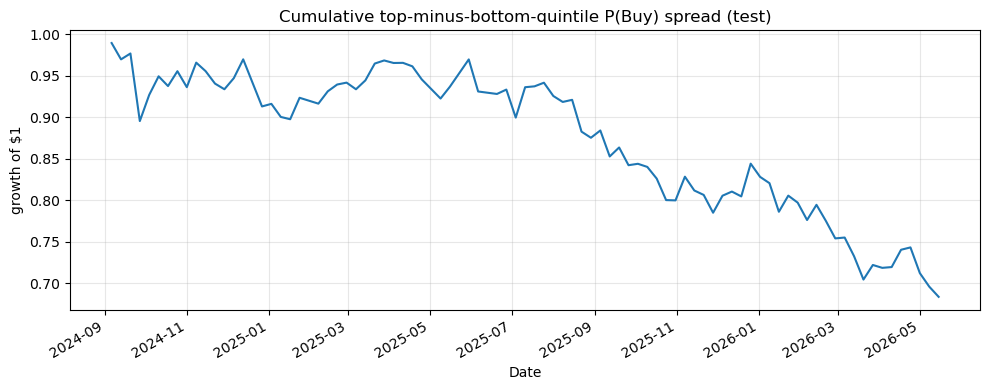

In [12]:
# Cross-sectional weekly long-short spread (top vs bottom P_Buy quintile).
def weekly_quintile_spread(df, q=5):
    recs = []
    for dt, g in df.groupby(level=0):
        if g["Stock"].nunique() < q * 2:
            continue
        ranks = g["P_Buy"].rank(pct=True)
        top = g.loc[ranks >= 1 - 1 / q, "Returns-future-1wk"].mean()
        bot = g.loc[ranks <= 1 / q,     "Returns-future-1wk"].mean()
        recs.append({"Date": dt, "top": top, "bottom": bot, "spread": top - bot})
    return pd.DataFrame(recs).set_index("Date").sort_index()

spread = weekly_quintile_spread(te)
ann = 52
if len(spread):
    mu, sd = spread["spread"].mean(), spread["spread"].std()
    sharpe = (mu * ann) / (sd * np.sqrt(ann)) if sd else np.nan
    print(f"weekly long-short spread: mean {mu:+.4%} | ann {mu*ann:+.2%} | "
          f"Sharpe {sharpe:.2f} | hit-rate {(spread['spread']>0).mean():.2%} "
          f"over {len(spread)} weeks")
    print("\nby year (mean weekly spread):")
    print((spread["spread"].groupby(spread.index.year).mean() * ann).round(4)
          .to_frame("ann_spread"))
    ax = (1 + spread["spread"].fillna(0)).cumprod().plot(
        figsize=(10, 4), title="Cumulative top-minus-bottom-quintile P(Buy) spread (test)")
    ax.set_ylabel("growth of $1"); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
else:
    print("not enough names per week for a quintile spread")

## 8. Feature importance (XGBoost gain)

                          gain
SP500-Log-Returns        45.19
SP500-Returns            43.74
Inflation                43.43
Bull_Probability         42.87
UnemploymentRate         39.10
InterestRate             37.50
Aroon                    30.26
Idio_Momentum_12wk       28.37
Idio_Momentum_26wk       20.75
RSI                      19.19
Volatility_Spike         16.19
Returns-1wk-0wklag       15.94
Returns-3wk-1wklag       15.02
Stochastic               13.38
SMA_5v20                 12.71
Idio_Mom_26wk*Bull_prob  12.65
MACD                     10.80
Idio_Momentum_4wk        10.02
OBV                       9.73
Beta_26wk                 9.25
ATR                       8.68
ADX                       6.39
Bollinger_Bands           0.00
Volume                    0.00


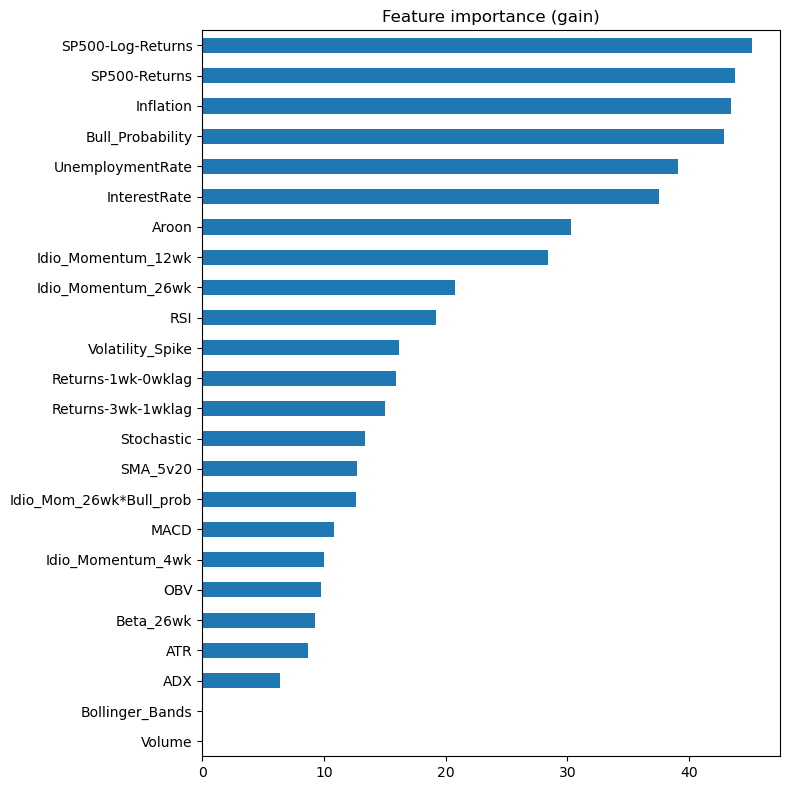

In [13]:
gain = model.get_booster().get_score(importance_type="gain")
imp = (pd.Series(gain).reindex(FEATURES).fillna(0)
       .sort_values(ascending=False).round(2))
print(imp.to_frame("gain"))
ax = imp[::-1].plot.barh(figsize=(8, 8), title="Feature importance (gain)")
plt.tight_layout(); plt.show()

## 9. Latest-week signal — whole universe ranked, portfolio ETFs flagged

In [14]:
latest = (panel_all.dropna(subset=FEATURES)
          .sort_index().groupby("Stock").tail(1).copy())
latest["P_Buy"] = model.predict_proba(latest[FEATURES])[:, 1]
latest["in_portfolio"] = latest["Stock"].isin(PORTFOLIO)
latest_tbl = (latest.reset_index()[["Date", "Stock", "P_Buy", "in_portfolio"]]
              .sort_values("P_Buy", ascending=False).reset_index(drop=True))
latest_tbl["P_Buy"] = latest_tbl["P_Buy"].round(4)
print(f"latest signals (as of {latest['Date'] if 'Date' in latest else latest.index.max()}):")
print("\n--- PORTFOLIO ETFs ---")
print(latest_tbl[latest_tbl["in_portfolio"]].to_string(index=False))
print("\n--- full universe (ranked) ---")
print(latest_tbl.to_string(index=False))

latest signals (as of 2026-05-29 00:00:00):

--- PORTFOLIO ETFs ---
      Date Stock  P_Buy  in_portfolio
2026-05-29   VBR 0.7068          True
2026-05-29  QUAL 0.6619          True
2026-05-29   VTV 0.6553          True
2026-05-29   VOO 0.6417          True
2026-05-29   QQQ 0.6361          True
2026-05-29   VGT 0.6128          True
2026-05-29  SOXX 0.5749          True

--- full universe (ranked) ---


      Date Stock  P_Buy  in_portfolio
2026-05-29   KRE 0.7649         False
2026-05-29   XME 0.7320         False
2026-05-29   XRT 0.7289         False
2026-05-29  SCHD 0.7288         False
2026-05-29  SPLV 0.7287         False
2026-05-29   XHB 0.7203         False
2026-05-29   VPU 0.7145         False
2026-05-29   VDE 0.7134         False
2026-05-29   VBR 0.7068          True
2026-05-29   VOE 0.7068         False
2026-05-29   XLU 0.6988         False
2026-05-29   KBE 0.6963         False
2026-05-29   XLE 0.6946         False
2026-05-29   RSP 0.6930         False
2026-05-29   IHI 0.6925         False
2026-05-29   XBI 0.6863         False
2026-05-29  JETS 0.6751         False
2026-05-29   XLV 0.6719         False
2026-05-29   VNQ 0.6690         False
2026-05-29  XLRE 0.6690         False
2026-05-29   VHT 0.6656         False
2026-05-29  QUAL 0.6619          True
2026-05-29  VLUE 0.6607         False
2026-05-29   TAN 0.6607         False
2026-05-29   VIG 0.6600         False
2026-05-29  

## 10. Takeaways (first run, test = 2024-09 → 2026-05)

**Timing skill, yes — selection skill, no.** Out-of-sample the model has weak
*time-series* skill: test ROC-AUC ≈ 0.58 and the P(Buy) buckets are monotonic in
realized next-week return (`<.30`: −1.6%, `.30–.70`: +0.4%, `>.70`: +1.0%). But it
has **negative cross-sectional skill**: the top-minus-bottom-quintile-by-P(Buy)
spread is ≈ −22%/yr (Sharpe ≈ −1.3, hit-rate 44%), negative in every test year.

**Why:** feature importance is dominated by **market-level** inputs
(`SP500-Log-Returns`, `SP500-Returns`, `Bull_Probability`, and the FRED macro
trio) that are *identical across all ETFs in a given week*. So P(Buy) collapses to
a single market-timing dial, not a per-ETF selector — the 7 portfolio ETFs come
out nearly tied (P(Buy) ≈ 0.47–0.54), and ranking the broad universe by P(Buy)
actually picks the following week's losers. `Bollinger_Bands` and `Volume`
contribute zero gain.

**Consistent with prior work:** this mirrors the stock-side conclusion
(`memory/project_macro_path_abandoned.md`: "no cross-sectional signal") and the
equal-weight-beats-concentration verdict (`memory/project_backtest_no_edge.md`).
For correlated US-equity ETFs there is no exploitable cross-sectional buy/sell
edge here.

**Implications / next steps:**
- Don't expect ETF *selection* alpha from this signal. The only plausible uses are
  (a) an aggregate **market-timing / cash overlay** driven by the universe-mean
  P(Buy), or (b) just equal-weighting the basket.
- Any construction must be judged by a **walk-forward weighted backtest vs SPY and
  equal-weight** (net of cost) before being trusted — reuse
  `src/backtest_lib.walk_forward_backtest` with `min_train_rows` lowered.
- If genuine cross-sectional skill is the goal, the universe likely needs assets
  that actually diverge (the multi-asset option), or single stocks (the existing
  `Main.ipynb` pipeline) — not 60 near-collinear equity ETFs.